# Comprehensive Conflict Graph Topology Analysis
This notebook visualizes the topological properties of conflict graphs as a function of the privacy budget (epsilon), categorized by dataset and generation algorithm.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [16, 10]
pd.set_option('display.max_columns', None)

## 1. Load Data

In [2]:
df_path = "../outputs/graph_topology_summary.csv"
if not os.path.exists(df_path):
    print(f"File {df_path} not found.")
else:
    df = pd.read_csv(df_path)
    df = df.sort_values(['dataset', 'algorithm', 'eps'])
    display(df.head())

,dataset,algorithm,eps,filename,n_nodes,n_edges,n_active,max_degree,min_degree,avg_degree,var_degree,density,n_components,giant_size,rel_giant_size,max_clique,avg_eigenvector_centrality
46,adult,aim,0.1,graph_adult_aim_eps0.1_graph.graphml,48842,33846532,48842,47870,123,1385.960116,1.413653e+07,0.028377,1,48842,1.00000,-1,0.093883
6,adult,aim,0.2,graph_adult_aim_eps0.2_graph.graphml,48842,34908368,48842,48647,175,1429.440563,1.392341e+07,0.029267,1,48842,1.00000,-1,0.089577
73,adult,aim,0.3,graph_adult_aim_eps0.3_graph.graphml,48842,36518986,48842,48146,180,1495.392736,1.220274e+07,0.030618,1,48842,1.00000,-1,0.092819
40,adult,aim,0.4,graph_adult_aim_eps0.4_graph.graphml,48842,31232567,48841,48624,0,1278.922526,1.613863e+07,0.026185,2,48841,0.99998,-1,0.094397
35,adult,aim,0.5,graph_adult_aim_eps0.5_graph.graphml,48842,28409252,48842,48309,82,1163.312395,1.575840e+07,0.023818,1,48842,1.00000,-1,0.092364


## 2. Degree Analysis (Max, Avg, Min, Variance)
Visualizing the scale and skewness of node degrees.

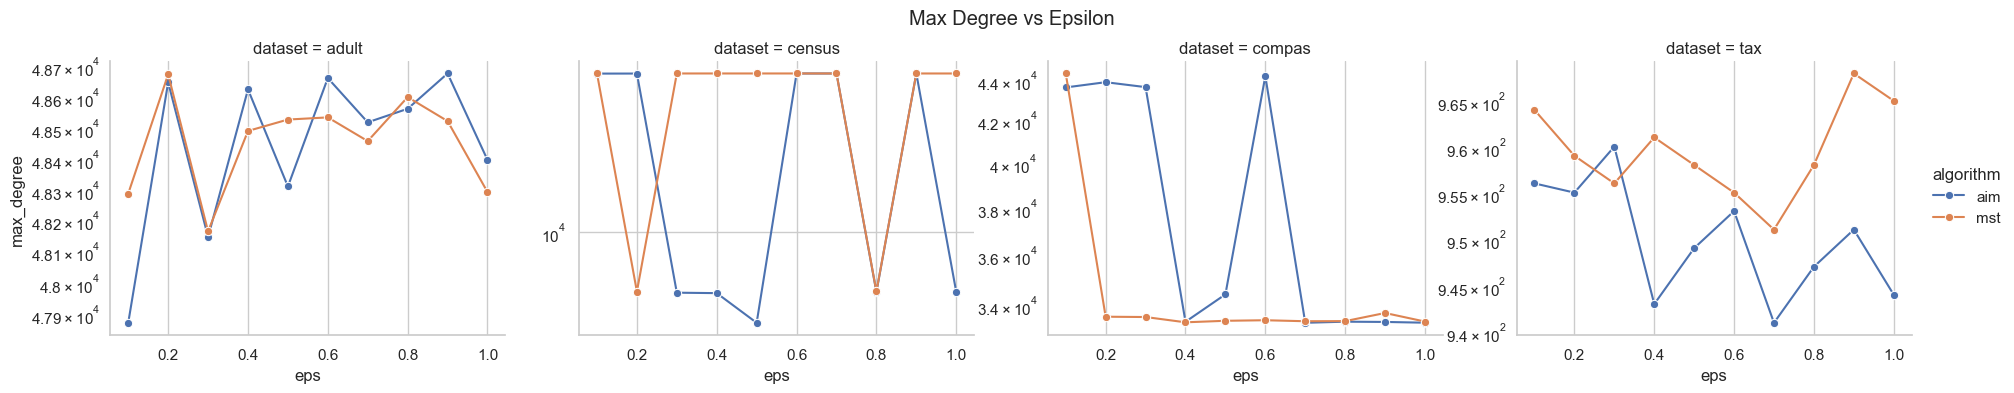

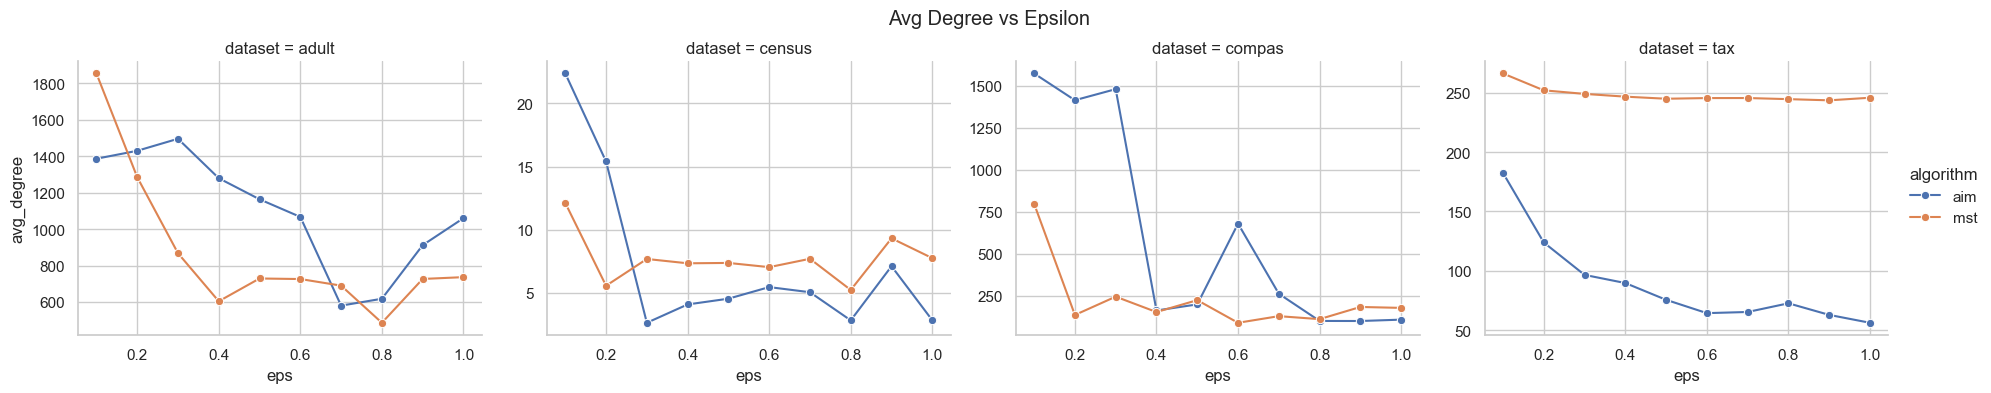

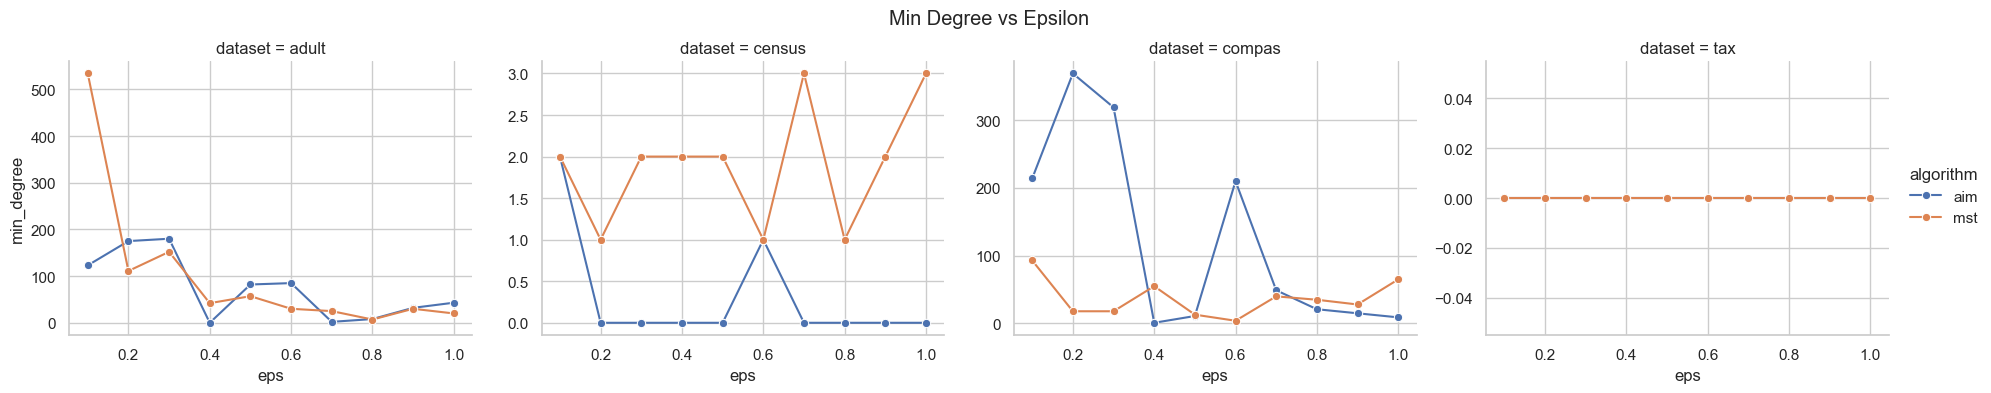

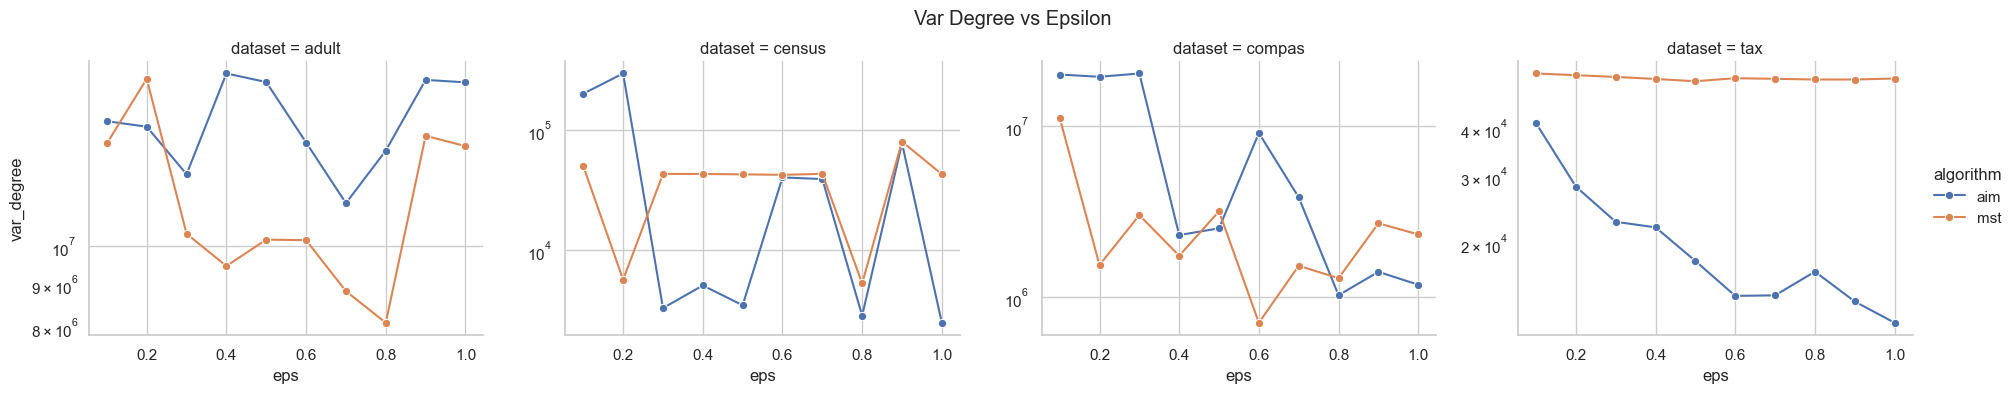

In [3]:
metrics = ['max_degree', 'avg_degree', 'min_degree', 'var_degree']
for metric in metrics:
    g = sns.FacetGrid(df, col="dataset", hue="algorithm", height=4, aspect=1.2, sharey=False)
    g.map(sns.lineplot, "eps", metric, marker="o")
    g.add_legend()
    if metric in ['max_degree', 'var_degree']:
        g.set(yscale="log")
    g.fig.suptitle(f"{metric.replace('_', ' ').title()} vs Epsilon")
    plt.subplots_adjust(top=0.85)
    plt.show()

## 3. Connectivity (Components & Giant Component)
How fragmented is the graph?

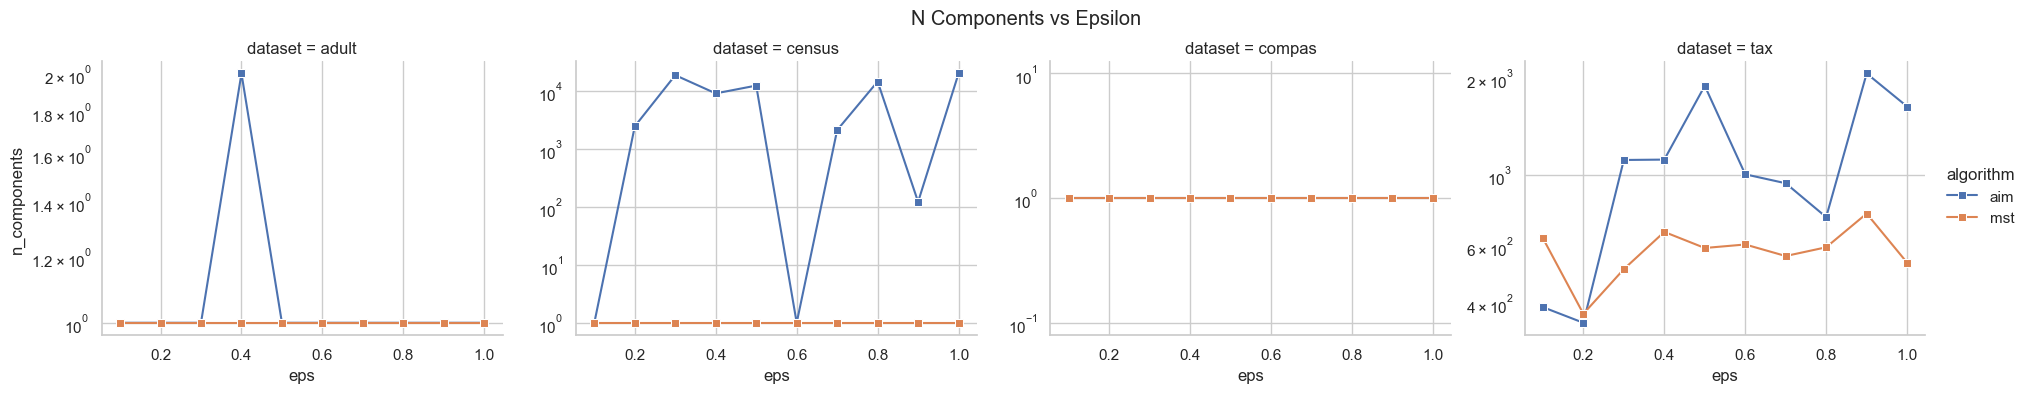

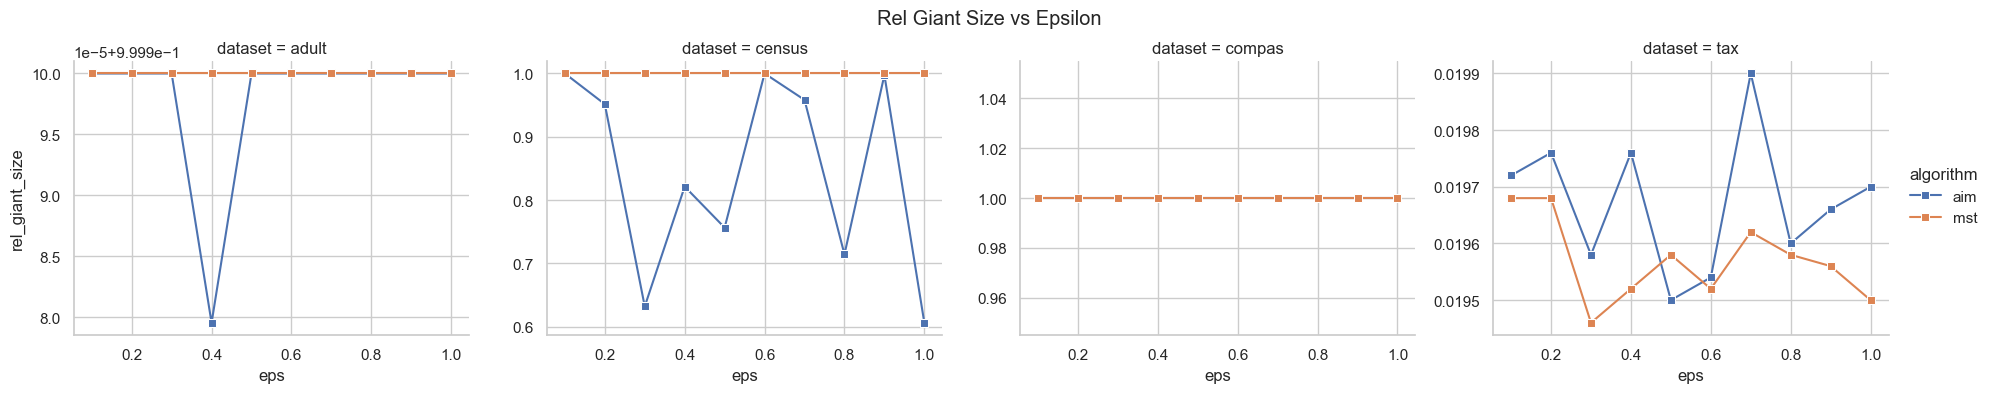

In [4]:
metrics = ['n_components', 'rel_giant_size']
for metric in metrics:
    g = sns.FacetGrid(df, col="dataset", hue="algorithm", height=4, aspect=1.2, sharey=False)
    g.map(sns.lineplot, "eps", metric, marker="s")
    g.add_legend()
    if metric == 'n_components':
        g.set(yscale="log")
    g.fig.suptitle(f"{metric.replace('_', ' ').title()} vs Epsilon")
    plt.subplots_adjust(top=0.85)
    plt.show()

## 4. Density & Clique
Visualizing the tightness of the conflict space.

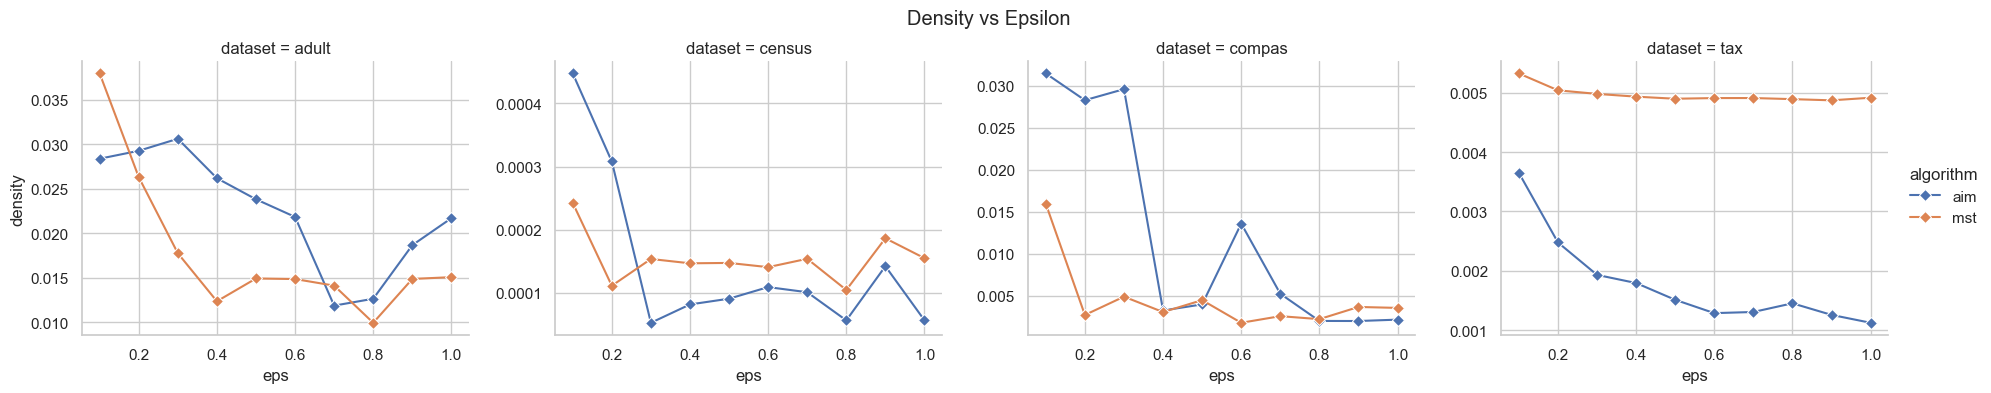

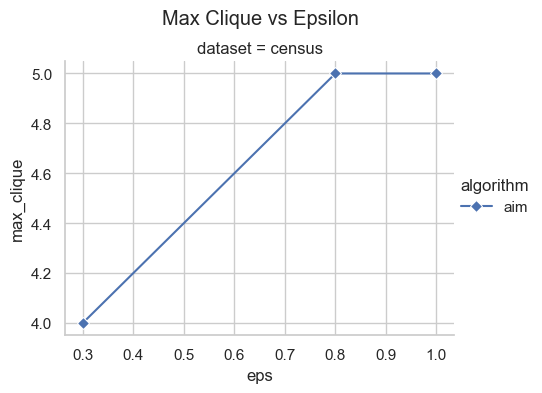

In [5]:
metrics = ['density', 'max_clique']
for metric in metrics:
    # For max_clique, filter out -1 (not calculated)
    plot_df = df[df[metric] != -1] if metric == 'max_clique' else df
    
    g = sns.FacetGrid(plot_df, col="dataset", hue="algorithm", height=4, aspect=1.2, sharey=False)
    g.map(sns.lineplot, "eps", metric, marker="D")
    g.add_legend()
    g.fig.suptitle(f"{metric.replace('_', ' ').title()} vs Epsilon")
    plt.subplots_adjust(top=0.85)
    plt.show()

## 5. Centrality
How concentrated are the conflicts?

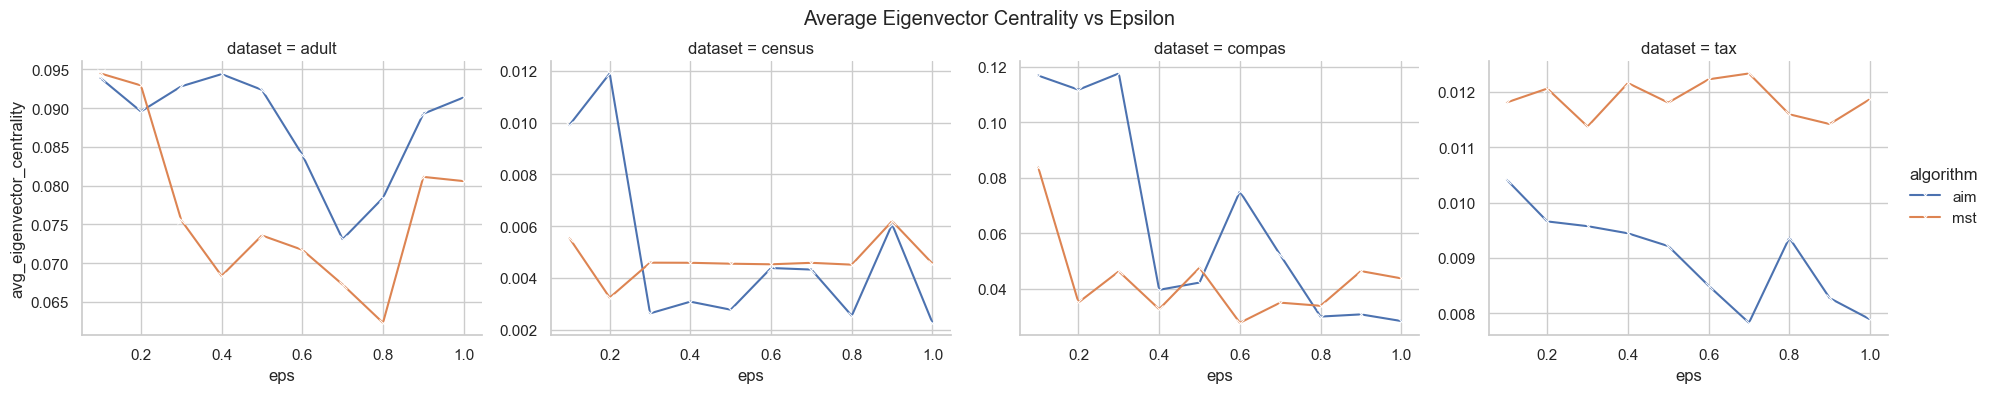

In [6]:
g = sns.FacetGrid(df, col="dataset", hue="algorithm", height=4, aspect=1.2, sharey=False)
g.map(sns.lineplot, "eps", "avg_eigenvector_centrality", marker="x")
g.add_legend()
g.fig.suptitle("Average Eigenvector Centrality vs Epsilon")
plt.subplots_adjust(top=0.85)
plt.show()

## 6. Numerical Summary Table

In [7]:
final_summary = df.pivot_table(
    index=['dataset', 'algorithm'], 
    columns='eps', 
    values=['max_degree', 'rel_giant_size', 'density']
)
display(final_summary)

density                                                    \
eps                     0.1       0.2       0.3       0.4       0.5       0.6   
dataset algorithm                                                               
adult   aim        0.028377  0.029267  0.030618  0.026185  0.023818  0.021837   
        mst        0.037955  0.026308  0.017757  0.012361  0.014921  0.014859   
census  aim        0.000448  0.000308  0.000053  0.000082  0.000091  0.000109   
        mst        0.000242  0.000111  0.000154  0.000147  0.000147  0.000141   
compas  aim        0.031487  0.028301  0.029618  0.003250  0.003976  0.013600   
        mst        0.015960  0.002715  0.004898  0.003064  0.004483  0.001785   
tax     aim        0.003650  0.002479  0.001933  0.001796  0.001514  0.001290   
        mst        0.005323  0.005039  0.004979  0.004933  0.004898  0.004909   

                                                          max_degree           \
eps                     0.7       0.8       0.9       1.0        0.1      0.2   
dataset algorithm                                                               
adult   aim        0.011872  0.012643  0.018665  0.021697    47870.0  48647.0   
        mst        0.014118  0.009944  0.014869  0.015071    48286.0  48673.0   
census  aim        0.000101  0.000057  0.000142  0.000057    42715.0  42734.0   
        mst        0.000154  0.000105  0.000186  0.000155    42766.0   5757.0   
compas  aim        0.005244  0.002005  0.001996  0.002160    43596.0  43858.0   
        mst        0.002575  0.002218  0.003669  0.003559    44298.0  33541.0   
tax     aim        0.001309  0.001455  0.001260  0.001127      956.0    955.0   
        mst        0.004910  0.004891  0.004871  0.004915      964.0    959.0   

                                                                         \
eps                    0.3      0.4      0.5      0.6      0.7      0.8   
dataset algorithm                                                         
adult   aim        48146.0  48624.0  48309.0  48661.0  48517.0  48561.0   
        mst        48164.0  48489.0  48526.0  48533.0  48456.0  48599.0   
census  aim         5697.0   5674.0   4320.0  42758.0  42761.0   5733.0   
        mst        42763.0  42767.0  42765.0  42767.0  42764.0   5760.0   
compas  aim        43612.0  33347.0  34409.0  44164.0  33309.0  33351.0   
        mst        33529.0  33327.0  33385.0  33406.0  33368.0  33372.0   
tax     aim          960.0    943.0    949.0    953.0    941.0    947.0   
        mst          956.0    961.0    958.0    955.0    951.0    958.0   

                                    rel_giant_size                             \
eps                    0.9      1.0            0.1      0.2      0.3      0.4   
dataset algorithm                                                               
adult   aim        48676.0  48395.0        1.00000  1.00000  1.00000  0.99998   
        mst        48521.0  48291.0        1.00000  1.00000  1.00000  1.00000   
census  aim        42754.0   5737.0        1.00000  0.95152  0.63200  0.82130   
        mst        42763.0  42757.0        1.00000  1.00000  1.00000  1.00000   
compas  aim        33341.0  33312.0        1.00000  1.00000  1.00000  1.00000   
        mst        33684.0  33355.0        1.00000  1.00000  1.00000  1.00000   
tax     aim          951.0    944.0        0.01972  0.01976  0.01958  0.01976   
        mst          968.0    965.0        0.01968  0.01968  0.01946  0.01952   

                                                                         
eps                    0.5      0.6      0.7      0.8      0.9      1.0  
dataset algorithm                                                        
adult   aim        1.00000  1.00000  1.00000  1.00000  1.00000  1.00000  
        mst        1.00000  1.00000  1.00000  1.00000  1.00000  1.00000  
census  aim        0.75648  1.00000  0.95828  0.71426  0.99760  0.60616  
        mst        1.00000  1.00000  1.00000  1.00000  1.00000  1.00000  
